Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import accuracy_score

Configuration

This section defines:
File paths for input data and output results
List of stock datasets used in the analysis
ARIMAX model parameters (order)

The ARIMAX order (p, d, q) controls:
p → autoregressive terms  
d → differencing (stationarity)  
q → moving average terms  

This ensures consistency across all experiments.


In [3]:
DATA_PATH = '../../data'
RESULTS_PATH = '../../data/results'

os.makedirs(RESULTS_PATH, exist_ok=True)

FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv'
}


ARIMA_ORDER = (1,1,1)

Load Raw Data & Engineer Features

Stock data is loaded and preprocessed as follows:

Convert date column to datetime format  
Set date as index  
Resample to weekly frequency (Friday close)  
Compute returns using percentage change  

Additional features:
Lagged returns (lag1, lag2)  capture momentum  
These act as exogenous variables for ARIMAX  

This prepares the dataset for time-series modeling.

In [44]:
df = df.loc[:, ~df.columns.duplicated()]

if isinstance(df['Close'], pd.DataFrame):
    df['Close'] = df['Close'].iloc[:, 0]

In [11]:
for name, path in FILES.items():
    
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    
    df = df.loc[:, ~df.columns.duplicated(keep='first')]
    
    if 'Adj Close' in df.columns:
        df['Close'] = df['Adj Close']
    
    if 'Close' not in df.columns:
        print(f"Skipping {name} (no Close column)")
        continue
    if df.columns.tolist().count('Close') > 1:
        close_cols = df.loc[:, df.columns == 'Close']
        df['Close'] = close_cols.iloc[:, 0] 
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
  
    df = df.resample('W-FRI').last()
    
    df['Return'] = df['Close'].pct_change()
    df['lag1'] = df['Return'].shift(1)
    df['lag2'] = df['Return'].shift(2)
    
    data[name] = df.dropna()

    print(f"{name} loaded successfully")

AAPL loaded successfully
MSFT loaded successfully
GOOGL loaded successfully
AMZN loaded successfully
NVDA loaded successfully
META loaded successfully
TSLA loaded successfully
JPM loaded successfully
GS loaded successfully
JNJ loaded successfully
XOM loaded successfully
CVX loaded successfully
WMT loaded successfully
BA loaded successfully


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_58638/2435386691.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


Train/Val/Test Split

In [12]:
split_date = '2022-01-01'

train_data = {}
test_data = {}

for stock in data:
    df = data[stock]
    train_data[stock] = df[df.index < split_date]
    test_data[stock] = df[df.index >= split_date]

Walk-Forward ARIMAX Model

A walk-forward validation approach is used: Model is trained on historical data. Predicts one step ahead. Actual value is then added to history.Process repeats for each time step  

This mimics real-world trading conditions where:
Only past data is available  
Models are continuously updated  

ARIMAX incorporates:
Time-series structure (ARIMA)
Exogenous variables (lag features)

This is computationally expensive but more realistic.

In [14]:
predictions_all = []

for stock in data:
    
    train = train_data[stock]
    test = test_data[stock]
    
    history_y = list(train['Return'])
    history_x = train[['lag1','lag2']].values.tolist()
    
    preds = []
    
    for i in range(len(test)):
        
        model = SARIMAX(history_y, exog=np.array(history_x), order=ARIMA_ORDER)
        model_fit = model.fit(disp=False)
        
        exog_test = test[['lag1','lag2']].iloc[i].values.reshape(1,-1)
        pred = model_fit.forecast(exog=exog_test)[0]
        
        preds.append(pred)
        
        # update history
        history_y.append(test['Return'].iloc[i])
        history_x.append(test[['lag1','lag2']].iloc[i].values.tolist())
    
    temp = test.copy()
    temp['Pred'] = preds
    temp['Stock'] = stock
    
    predictions_all.append(temp)

combined_pred = pd.concat(predictions_all)

/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/pihupawar/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary sta

Save Predictions

In [15]:
combined_pred.to_csv(f"{RESULTS_PATH}/arimax_predictions.csv")

Weekly Stock Rankings

Stocks are ranked each week based on predicted returns.

Higher predicted return → higher rank  
Ranking is performed cross-sectionally  

This enables: Stock selection strategies.  
Portfolio construction  

Ranking transforms predictions into actionable decisions.

In [16]:
combined_pred['Rank'] = combined_pred.groupby(combined_pred.index)['Pred'].rank(ascending=False)

Backtesting

A trading strategy is constructed:

Select top-ranked stock each week  
Apply next week's return (to avoid lookahead bias)  

Benchmark:
Equal-weight average of all stocks (Buy & Hold)

Key considerations:
No future information is used  
Realistic execution timing  

This evaluates how the model performs in practice.

In [43]:
best = combined_pred.loc[
    combined_pred.groupby(combined_pred.index)['Pred'].idxmax()
].copy()

best['Next_Return'] = best['Return'].shift(-1)
best['Strategy_Return'] = best['Next_Return']

best = best.dropna()

best['Portfolio'] = (1 + best['Strategy_Return']).cumprod()

benchmark = combined_pred.groupby(combined_pred.index)['Return'].mean()
benchmark = (1 + benchmark).cumprod()

Performance Metrics

Key performance metrics include:
Total Return → overall growth of portfolio  
Sharpe Ratio → risk-adjusted return  
Max Drawdown → worst loss from peak  

These metrics provide a comprehensive evaluation of Profitability, Risk, Stability  
They are essential for comparing strategies.

In [18]:
returns = best['Strategy_Return']

sharpe = returns.mean() / returns.std() * np.sqrt(52)
total_return = best['Portfolio'].iloc[-1]

drawdown = (best['Portfolio'] / best['Portfolio'].cummax()) - 1

print("Total Return:", total_return)
print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", drawdown.min())

Total Return: 10325.162451947865
Sharpe Ratio: 0.6305067687853166
Max Drawdown: -0.987234988136619


Directional Accuracy Bar Chart

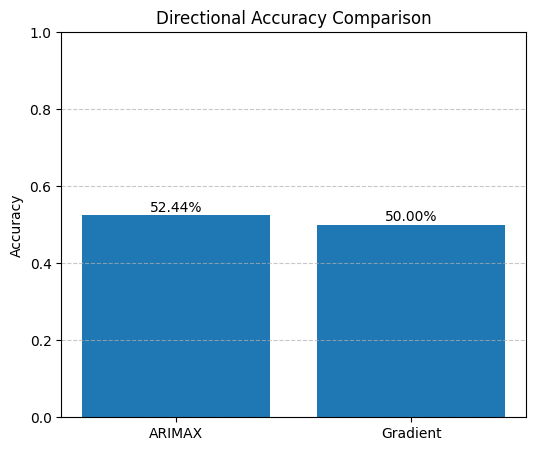

In [35]:
combined_pred['Actual_Dir'] = (combined_pred['Return'] > 0).astype(int)
combined_pred['Pred_Dir'] = (combined_pred['Pred'] > 0).astype(int)

accuracy = (combined_pred['Actual_Dir'] == combined_pred['Pred_Dir']).mean()

random_acc = 0.5
plt.figure(figsize=(6,5))

models = ['ARIMAX', 'Gradient']
values = [accuracy, random_acc]

plt.bar(models, values)
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Directional Accuracy Comparison")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Actual vs Predicted Returns

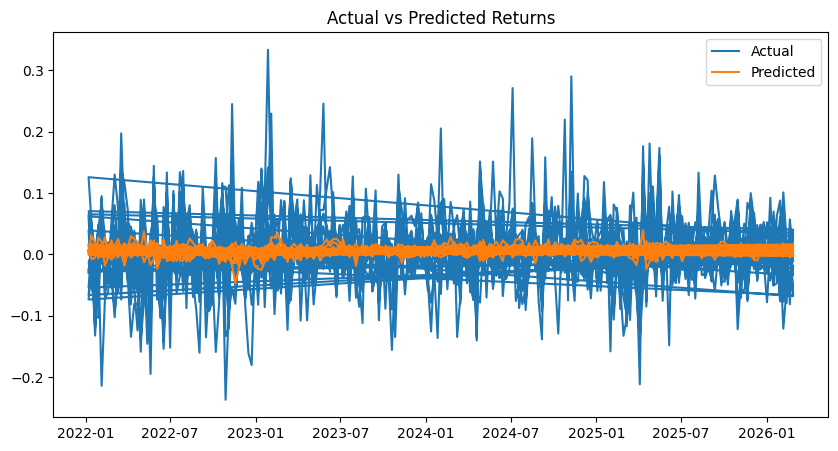

In [36]:
plt.figure(figsize=(10,5))
plt.plot(combined_pred['Return'], label='Actual')
plt.plot(combined_pred['Pred'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Returns")
plt.show()

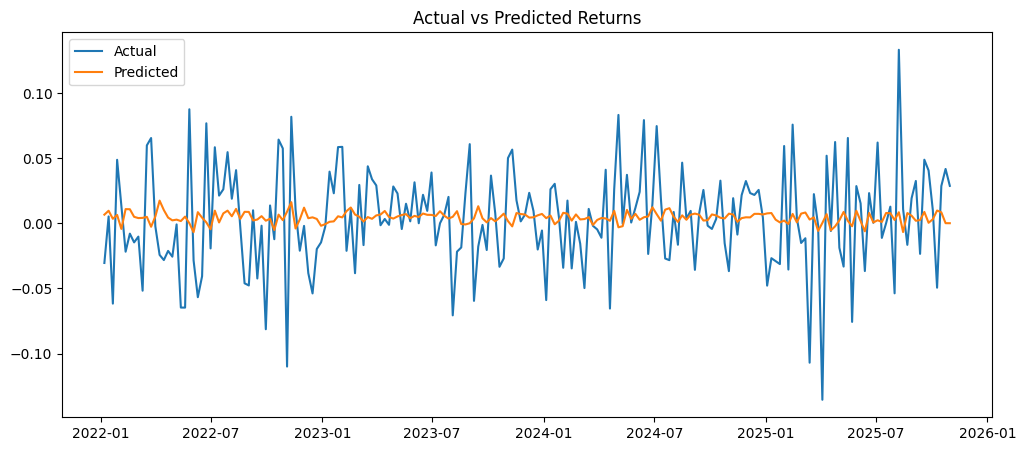

In [30]:
Clean = combined_pred.iloc[:200]

plt.figure(figsize=(12,5))
plt.plot(sample['Return'], label='Actual')
plt.plot(sample['Pred'], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Returns")
plt.show()

Backtest — Strategy vs Buy & Hold

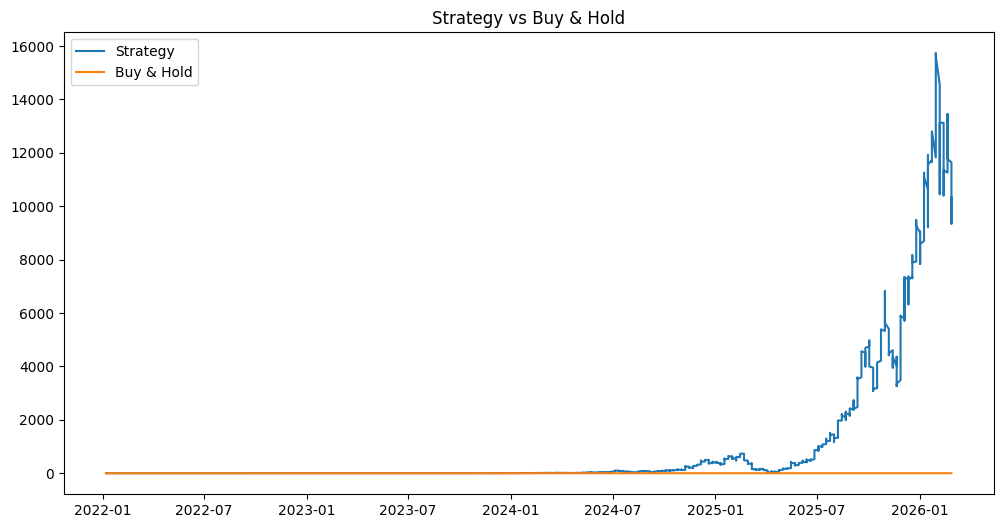

In [21]:
plt.figure(figsize=(12,6))
plt.plot(best['Portfolio'], label='Strategy')
plt.plot(benchmark, label='Buy & Hold')

plt.legend()
plt.title("Strategy vs Buy & Hold")
plt.show()

Save Summary

In [22]:
summary = {
    'Total Return': total_return,
    'Sharpe': sharpe,
    'Max Drawdown': drawdown.min()
}

pd.DataFrame([summary]).to_csv(f"{RESULTS_PATH}/arimax_summary.csv")

Cumulative Returns Comparison

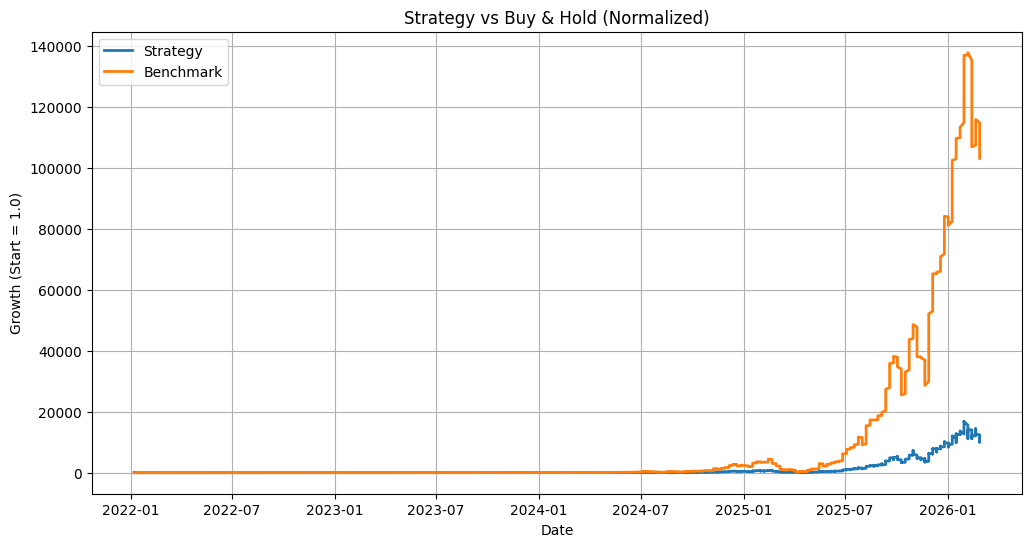

In [37]:
best = combined_pred.loc[
    combined_pred.groupby(combined_pred.index)['Pred'].idxmax()
].copy()

best['Next_Return'] = best['Return'].shift(-1)

best['Strategy_Return'] = best['Next_Return']

best = best.dropna()

best['Strategy_Cum'] = (1 + best['Strategy_Return']).cumprod()
best['Strategy_Cum'] = best['Strategy_Cum'] / best['Strategy_Cum'].iloc[0]

benchmark = combined_pred.groupby(combined_pred.index)['Return'].mean()

benchmark = benchmark.loc[best.index]  # align dates

benchmark_cum = (1 + benchmark).cumprod()
benchmark_cum = benchmark_cum / benchmark_cum.iloc[0]

plt.figure(figsize=(12,6))

plt.plot(best.index, best['Strategy_Cum'], label='Strategy', linewidth=2)
plt.plot(benchmark_cum.index, benchmark_cum, label='Benchmark', linewidth=2)

plt.title("Strategy vs Buy & Hold (Normalized)")
plt.xlabel("Date")
plt.ylabel("Growth (Start = 1.0)")
plt.legend()
plt.grid()

plt.show()

Weekly Returns Distribution

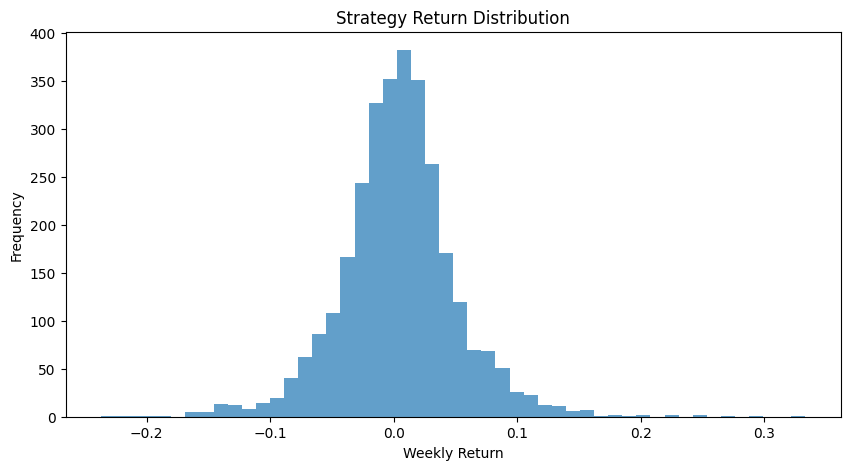

In [38]:
plt.figure(figsize=(10,5))

plt.hist(best['Strategy_Return'], bins=50, alpha=0.7)

plt.title("Strategy Return Distribution")
plt.xlabel("Weekly Return")
plt.ylabel("Frequency")

plt.show()

Drawdown Plot

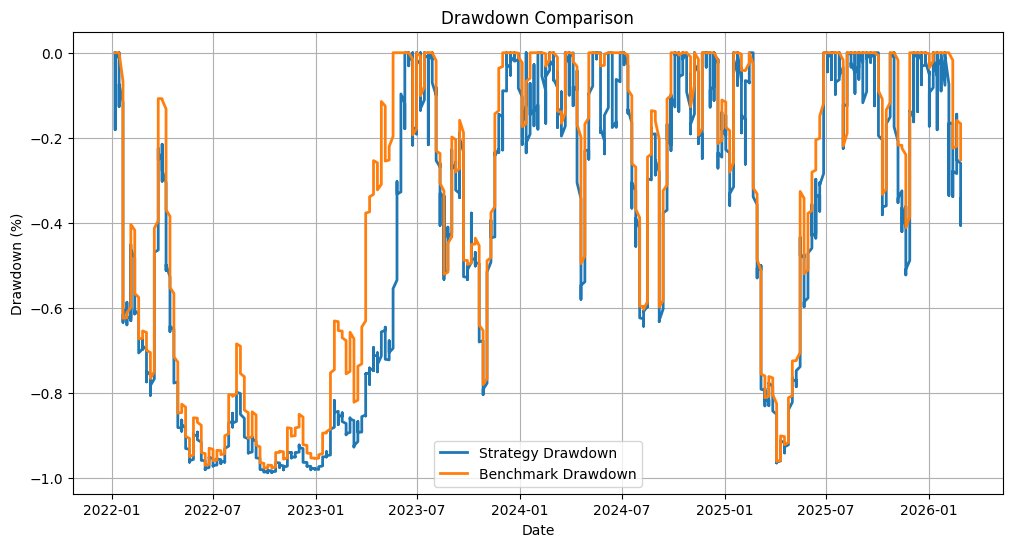

In [40]:
strategy_cum = best['Strategy_Cum']

strategy_drawdown = (strategy_cum / strategy_cum.cummax()) - 1
benchmark_cum = benchmark_cum  

benchmark_drawdown = (benchmark_cum / benchmark_cum.cummax()) - 1

plt.figure(figsize=(12,6))

plt.plot(strategy_drawdown, label='Strategy Drawdown', linewidth=2)
plt.plot(benchmark_drawdown, label='Benchmark Drawdown', linewidth=2)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.legend()
plt.grid()

plt.show()

Top Stock Selection Over Time

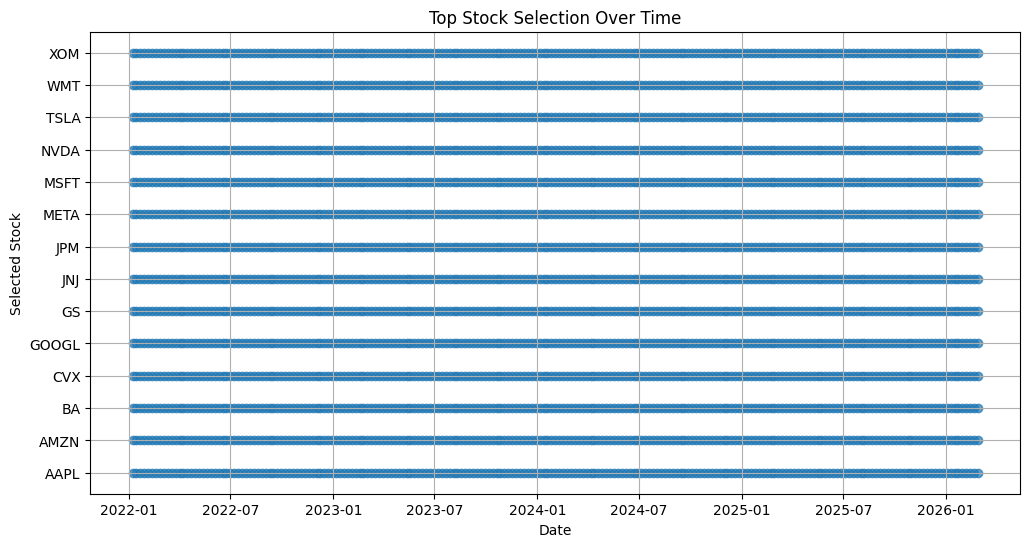

In [41]:
top_selection = combined_pred.loc[
    combined_pred.groupby(combined_pred.index)['Pred'].idxmax()
].copy()

top_selection = top_selection.reset_index()

top_selection['Stock_Code'] = top_selection['Stock'].astype('category').cat.codes

stock_labels = dict(enumerate(top_selection['Stock'].astype('category').cat.categories))
plt.figure(figsize=(12,6))

plt.scatter(
    top_selection['Date'],
    top_selection['Stock_Code'],
    alpha=0.7
)

plt.yticks(
    ticks=list(stock_labels.keys()),
    labels=list(stock_labels.values())
)

plt.title("Top Stock Selection Over Time")
plt.xlabel("Date")
plt.ylabel("Selected Stock")

plt.grid()

plt.show()

Rolling Sharpe Ratio

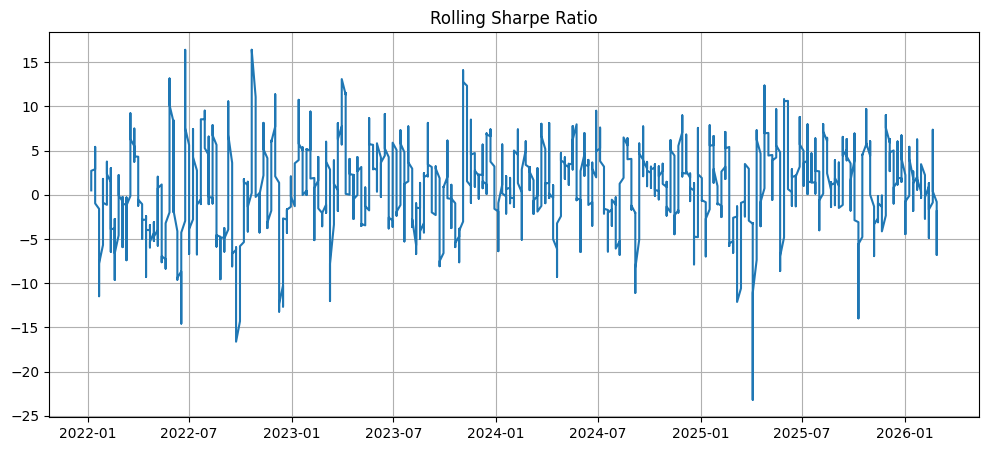

In [42]:
rolling_sharpe = (
    best['Strategy_Return']
    .rolling(12)
    .mean() / best['Strategy_Return'].rolling(12).std()
) * np.sqrt(52)

plt.figure(figsize=(12,5))
plt.plot(rolling_sharpe)

plt.title("Rolling Sharpe Ratio")
plt.grid()
plt.show()